# ECOWAS Border Intelligence Analytics Platform (EBIAP)

# Time Series Analysis and Forecasting

## Impact Assessment of Simulated Regional Trade Diversion Following the AES Countries' Withdrawal from ECOWAS

### Case Study: Tsamiya–Kamba Transit Corridor

---

## Project Objective

This notebook demonstrates how time series analysis can be applied to forecast future border trade activities using historical transaction data.

Forecasting enables border authorities and policymakers to anticipate changes in trade volume, customs revenue, and operational workload, thereby improving planning, resource allocation, and strategic decision-making.

---

## Business Problem

Following significant regional policy changes such as the withdrawal of AES countries from ECOWAS, border trade patterns may shift over time. Border agencies require forecasting tools to estimate future trends in trade volume and customs revenue.

This notebook develops a simple forecasting workflow to demonstrate how predictive analytics can support proactive border management.

---

## Expected Outcomes

By the end of this notebook, readers will understand how to:

- Prepare time series data.
- Aggregate monthly border trade statistics.
- Visualize historical trends.
- Generate simple forecasts.
- Interpret forecast results for decision-making.

In [28]:
# ============================================================
# Chapter 1 - Import Libraries
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [29]:
# ============================================================
# Chapter 2 - Load Dataset
# ============================================================

df = pd.read_csv("trade_diversion_transactions.csv")

print(df.shape)

df.head()

(100000, 20)


,Transaction_ID,Transaction_Date,Period,Origin_Country,Entry_Country,Destination_Country,Border_Post,Commodity,Vehicle_Type,Cargo_Weight_kg,Trade_Value_USD,Customs_Duty_USD,Revenue_Collected_USD,Queue_Length,Processing_Time_Minutes,Inspection_Result,Smuggling_Risk,Security_Incident,Scanner_Status,Border_Efficiency_Score
0,TRX0000001,2025-08-02,After Diversion,Togo,Cape Verde,Niger,Praia Port,Vehicles,Heavy Truck,23091.78,70960.57,9435.26,9791.44,17,25.9,Passed,Medium,No,Unavailable,98.0
1,TRX0000002,2022-08-17,Before Diversion,Nigeria,Togo,Niger,Kodjoviakope,Livestock,Heavy Truck,16533.94,63340.83,11608.49,11799.07,22,48.0,Passed,Low,No,Unavailable,82.3
2,TRX0000003,2022-02-21,Before Diversion,Benin,Benin,Niger,Hillacondji,Vehicles,Passenger Bus,943.86,13943.07,2766.44,2833.49,25,46.5,Passed,Medium,No,Unavailable,76.8
3,TRX0000004,2023-07-18,Before Diversion,Benin,Sierra Leone,Nigeria,Gbalamuya,Petroleum,Heavy Truck,18142.28,83276.36,13714.69,13775.83,6,20.5,Passed,Medium,No,Available,95.3
4,TRX0000005,2023-05-17,Before Diversion,Benin,Mali,Nigeria,Gogui,Vehicles,Heavy Truck,19017.79,62190.16,10388.67,10554.40,26,54.9,Passed,Low,No,Available,79.7


# Data Preparation

Convert the transaction date into a proper datetime format and create additional time-related variables for analysis.

In [30]:
# ============================================================
# Chapter 3 - Date Preparation
# ============================================================

df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"])

df["Year"] = df["Transaction_Date"].dt.year

df["Month"] = df["Transaction_Date"].dt.month

df["Month_Name"] = df["Transaction_Date"].dt.month_name()

df["Quarter"] = df["Transaction_Date"].dt.quarter

print("Date variables created successfully.")

Date variables created successfully.


# Monthly Trade Summary

Aggregate monthly trade values and customs revenue to prepare the data for trend analysis and forecasting.

In [31]:
# ============================================================
# Chapter 4 - Monthly Summary
# ============================================================

monthly_trade = (

    df.groupby(
        pd.Grouper(
            key="Transaction_Date",
            freq="M"
        )
    )

    .agg({

        "Trade_Value_USD":"sum",

        "Revenue_Collected_USD":"sum",

        "Transaction_ID":"count"

    })

    .reset_index()

)

monthly_trade.rename(columns={

    "Transaction_ID":"Transactions"

}, inplace=True)

monthly_trade.head()

/tmp/ipykernel_2418/995514858.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(


,Transaction_Date,Trade_Value_USD,Revenue_Collected_USD,Transactions
0,2022-01-31,1.145106e+08,14692661.12,2153
1,2022-02-28,1.033415e+08,13349102.20,1909
2,2022-03-31,1.115754e+08,14389160.64,2080
3,2022-04-30,1.097885e+08,14069010.90,2051
4,2022-05-31,1.134172e+08,14487972.42,2123



# Historical Trend

Visualize historical customs revenue over time to identify trends and seasonal patterns.



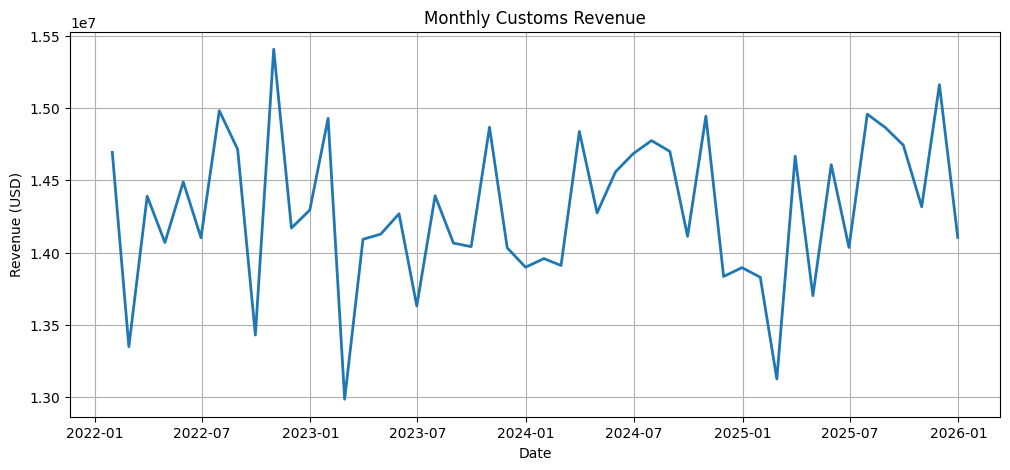

In [32]:
# ============================================================
# Chapter 5 - Historical Trend
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(

    monthly_trade["Transaction_Date"],

    monthly_trade["Revenue_Collected_USD"],

    linewidth=2

)

plt.title("Monthly Customs Revenue")

plt.xlabel("Date")

plt.ylabel("Revenue (USD)")

plt.grid(True)

plt.show()

## Chapter 6 - Top 20 Highest-Risk Transactions

In border intelligence operations, identifying the highest-risk transactions is essential for effective resource deployment. Rather than inspecting every shipment equally, border agencies prioritize inspections based on calculated risk levels.

This chapter identifies the twenty transactions with the highest composite risk scores. These records represent the most critical cases requiring immediate attention and can support targeted inspections, investigations, and operational decision-making.

In [33]:
# ============================================================
# Chapter 5A - Create Risk Score
# ============================================================

risk_mapping = {

    "Low": 1,

    "Medium": 2,

    "High": 3

}

df["risk_score"] = df["Smuggling_Risk"].map(risk_mapping)

print(df[["Smuggling_Risk","risk_score"]].head())

  Smuggling_Risk  risk_score
0         Medium           2
1            Low           1
2         Medium           2
3         Medium           2
4            Low           1


In [34]:
# ============================================================
# Chapter 6 - Top 20 Highest-Risk Transactions
# ============================================================

top20 = (

    df.sort_values(

        by="risk_score",

        ascending=False

    )

    .head(20)

)

top20

,Transaction_ID,Transaction_Date,Period,Origin_Country,Entry_Country,Destination_Country,Border_Post,Commodity,Vehicle_Type,Cargo_Weight_kg,...,Inspection_Result,Smuggling_Risk,Security_Incident,Scanner_Status,Border_Efficiency_Score,Year,Month,Month_Name,Quarter,risk_score
5,TRX0000006,2023-04-03,Before Diversion,Cote d'Ivoire,Togo,Niger,Kodjoviakope,Fertilizer,Trailer,28190.42,...,Failed,High,No,Unavailable,79.9,2023,4,April,2,3
8,TRX0000009,2025-10-17,After Diversion,Cote d'Ivoire,Mali,Nigeria,Gogui,Rice,Trailer,33527.25,...,Passed,High,Yes,Available,75.0,2025,10,October,4,3
9,TRX0000010,2025-01-21,After Diversion,Benin,Burkina Faso,Nigeria,Cinkanse,Construction Materials,Trailer,32537.64,...,Failed,High,No,Unavailable,81.9,2025,1,January,1,3
13,TRX0000014,2022-03-07,Before Diversion,Nigeria,Cape Verde,Niger,Praia Port,Petroleum,Medium Truck,10035.61,...,Passed,High,No,Unavailable,76.3,2022,3,March,1,3
60536,TRX0060537,2023-10-04,Before Diversion,Senegal,Ghana,Nigeria,Elubo,Pharmaceuticals,Medium Truck,10442.07,...,Passed,High,No,Unavailable,91.9,2023,10,October,4,3
60539,TRX0060540,2023-07-31,Before Diversion,Guinea,Guinea-Bissau,Mali,Sao Domingos,Electronics,Medium Truck,12914.03,...,Passed,High,No,Available,71.5,2023,7,July,3,3
60513,TRX0060514,2022-07-31,Before Diversion,Benin,The Gambia,Nigeria,Amdallai,Rice,Medium Truck,12120.15,...,Passed,High,No,Unavailable,80.0,2022,7,July,3,3
60517,TRX0060518,2022-08-12,Before Diversion,Ghana,Niger,Nigeria,Konni,Agricultural Produce,Heavy Truck,22689.30,...,Passed,High,No,Available,81.2,2022,8,August,3,3
60524,TRX0060525,2023-04-01,Before Diversion,Benin,Ghana,Nigeria,Aflao,Livestock,Trailer,25330.96,...,Passed,High,No,Available,68.7,2023,4,April,2,3
99964,TRX0099965,2022-12-29,Before Diversion,Guinea,Nigeria,Nigeria,Tsamiya,Electronics,Passenger Bus,465.36,...,Passed,High,No,Available,79.6,2022,12,December,4,3


## Chapter 7 - Export Top 20 Highest-Risk Transactions

To support further analysis and reporting, the identified high-risk transactions are exported as a separate dataset. This file can be shared with operational teams, incorporated into dashboards, or used as input for future machine learning models and intelligence systems.

In [35]:
# ============================================================
# Chapter 7 - Export Top 20 Highest-Risk Transactions
# ============================================================

top20.to_csv(

    "top20_high_risk_transactions.csv",

    index=False

)

print(

    "Top 20 highest-risk transactions exported successfully."

)

Top 20 highest-risk transactions exported successfully.


## Chapter 8 - Border Risk Ranking

Different border posts experience varying levels of operational risk due to differences in trade volume, security challenges, smuggling activities, infrastructure, and geographic location.

This chapter calculates the average risk score for each border post and ranks them from the highest-risk to the lowest-risk locations. The results provide valuable insights for operational planning, personnel deployment, and resource allocation.

In [36]:
# ============================================================
# Chapter 8 - Border Risk Ranking
# ============================================================

border_rank = (

    df.groupby(

        "Border_Post"

    )

    .agg(

        Average_Risk=("risk_score", "mean"),

        Total_Transactions=("risk_score", "count")

    )

    .sort_values(

        by="Average_Risk",

        ascending=False

    )

)

border_rank

,Average_Risk,Total_Transactions
Border_Post,,
Hillacondji,1.878838,6611
Pogo,1.876171,2988
Noe,1.874051,2898
Elubo,1.873614,2706
Praia Port,1.873521,2451
Kouremale,1.866581,4662
Gaya,1.865867,5338
Bo Waterside,1.864407,3540
Konni,1.862031,5436


## Chapter 8 - Border Risk Ranking

Different border posts experience varying levels of operational risk due to differences in trade volume, security challenges, smuggling activities, infrastructure, and geographic location.

This chapter calculates the average risk score for each border post and ranks them from the highest-risk to the lowest-risk locations. The results provide valuable insights for operational planning, personnel deployment, and resource allocation.

## Chapter 9 - Visualize Border Risk Ranking

Visualizing border risk rankings provides an intuitive understanding of operational priorities across the ECOWAS region. The chart highlights border posts with elevated average risk scores, allowing decision-makers to quickly identify locations requiring enhanced surveillance, additional inspections, or increased resource allocation.

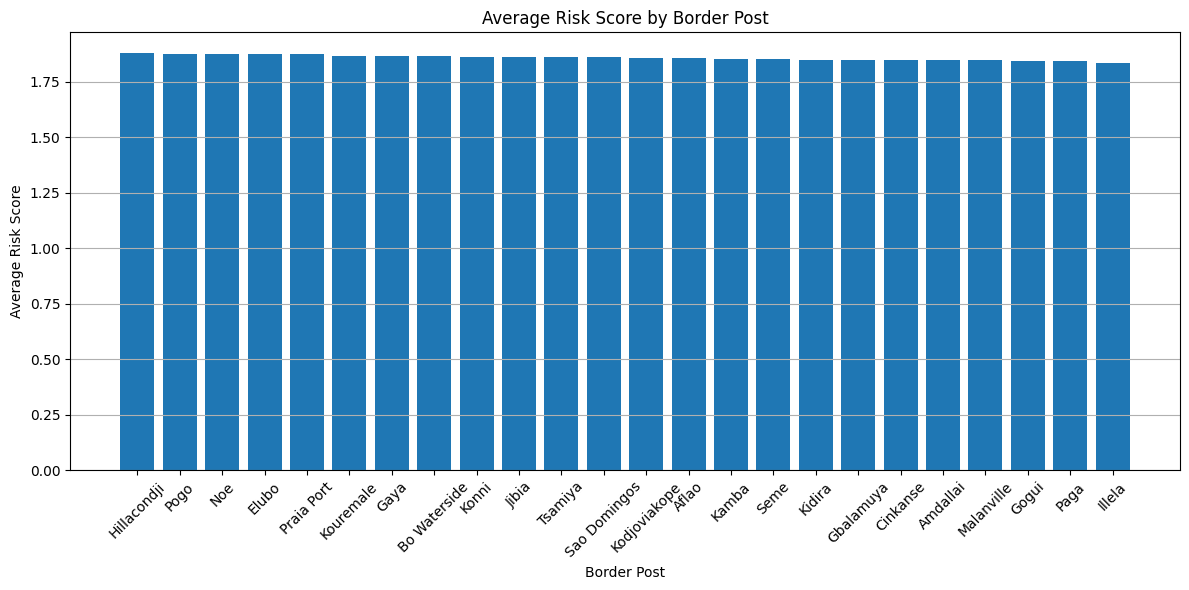

In [37]:
# ============================================================
# Chapter 9 - Visualize Border Risk Ranking
# ============================================================

plt.figure(

    figsize=(12,6)

)

plt.bar(

    border_rank.index,

    border_rank["Average_Risk"]

)

plt.title(

    "Average Risk Score by Border Post"

)

plt.xlabel(

    "Border Post"

)

plt.ylabel(

    "Average Risk Score"

)

plt.xticks(

    rotation=45

)

plt.grid(

    axis="y"

)

plt.tight_layout()

plt.show()

## Chapter 10 - Export Border Risk Ranking

The ranked border risk dataset is exported for future reporting and integration into business intelligence tools. This output can be incorporated into dashboards, executive reports, and the final Streamlit application to support evidence-based decision-making.

In [38]:
# ============================================================
# Chapter 10 - Export Border Risk Ranking
# ============================================================

border_rank.to_csv(

    "border_risk_ranking.csv"

)

print(

    "Border risk ranking exported successfully."

)

Border risk ranking exported successfully.


## Chapter 11 - Country Risk Ranking

Border risks often vary across neighboring countries due to differences in trade patterns, enforcement capacity, political stability, and cross-border activities.

This chapter aggregates transaction risk scores at the country level to identify regional patterns and support strategic planning across ECOWAS member states.

In [39]:
# ============================================================
# Chapter 11 - Entry Country Risk Ranking
# ============================================================

country_rank = (

    df.groupby("Entry_Country")

    .agg(

        Average_Risk=("risk_score", "mean"),

        Total_Transactions=("risk_score", "count")

    )

    .reset_index()

)

country_rank["Average_Risk"] = country_rank["Average_Risk"].round(2)

country_rank = country_rank.sort_values(

    by="Average_Risk",

    ascending=False

)

country_rank

,Entry_Country,Average_Risk,Total_Transactions
3,Cote d'Ivoire,1.88,5886
5,Guinea,1.87,4662
2,Cape Verde,1.87,2451
4,Ghana,1.86,8031
0,Benin,1.86,13244
6,Guinea-Bissau,1.86,2970
7,Liberia,1.86,3540
14,Togo,1.86,6100
9,Niger,1.86,10774
1,Burkina Faso,1.85,5504


## Origin Country Risk Ranking

This analysis ranks countries where shipments originated based on the average smuggling risk score.

## Chapter 12 - Visualize Country Risk Ranking

This visualization compares the average risk scores across countries represented in the dataset. The chart provides a high-level overview of regional risk patterns and supports strategic decision-making regarding cross-border cooperation, intelligence sharing, and security operations.

In [40]:
# ============================================================
# Chapter 11A - Origin Country Risk Ranking
# ============================================================

origin_rank = (

    df.groupby("Origin_Country")

    .agg(

        Average_Risk=("risk_score", "mean"),

        Total_Transactions=("risk_score", "count")

    )

    .reset_index()

)

origin_rank["Average_Risk"] = origin_rank["Average_Risk"].round(2)

origin_rank = origin_rank.sort_values(

    by="Average_Risk",

    ascending=False

)

origin_rank

,Origin_Country,Average_Risk,Total_Transactions
13,The Gambia,1.88,1948
4,Ghana,1.87,7968
3,Cote d'Ivoire,1.87,11990
9,Niger,1.87,4895
14,Togo,1.86,7004
2,Cape Verde,1.86,1011
0,Benin,1.86,30149
7,Liberia,1.86,3050
6,Guinea-Bissau,1.85,1989
1,Burkina Faso,1.85,4993


## Entry Country Risk Ranking

This analysis evaluates the average smuggling risk associated with the country through which goods entered the trade corridor.

In [41]:
# ============================================================
# Chapter 11B - Entry Country Risk Ranking
# ============================================================

entry_rank = (

    df.groupby("Entry_Country")

    .agg(

        Average_Risk=("risk_score", "mean"),

        Total_Transactions=("risk_score", "count")

    )

    .reset_index()

)

entry_rank["Average_Risk"] = entry_rank["Average_Risk"].round(2)

entry_rank = entry_rank.sort_values(

    by="Average_Risk",

    ascending=False

)

entry_rank

,Entry_Country,Average_Risk,Total_Transactions
3,Cote d'Ivoire,1.88,5886
5,Guinea,1.87,4662
2,Cape Verde,1.87,2451
4,Ghana,1.86,8031
0,Benin,1.86,13244
6,Guinea-Bissau,1.86,2970
7,Liberia,1.86,3540
14,Togo,1.86,6100
9,Niger,1.86,10774
1,Burkina Faso,1.85,5504


## Destination Country Risk Ranking

This analysis ranks destination countries according to the average smuggling risk of shipments received.

In [42]:
# ============================================================
# Chapter 11C - Destination Country Risk Ranking
# ============================================================

destination_rank = (

    df.groupby("Destination_Country")

    .agg(

        Average_Risk=("risk_score", "mean"),

        Total_Transactions=("risk_score", "count")

    )

    .reset_index()

)

destination_rank["Average_Risk"] = destination_rank["Average_Risk"].round(2)

destination_rank = destination_rank.sort_values(

    by="Average_Risk",

    ascending=False

)

destination_rank

,Destination_Country,Average_Risk,Total_Transactions
0,Burkina Faso,1.86,10190
2,Niger,1.86,47035
3,Nigeria,1.86,30308
1,Mali,1.85,12467


## Export Risk Ranking Reports

Export the generated risk ranking tables for use in Power BI dashboards, Streamlit applications, and executive reporting.

In [43]:
# ============================================================
# Chapter 12 - Export Risk Rankings
# ============================================================

origin_rank.to_csv(
    "origin_country_risk_ranking.csv",
    index=False
)

entry_rank.to_csv(
    "entry_country_risk_ranking.csv",
    index=False
)

destination_rank.to_csv(
    "destination_country_risk_ranking.csv",
    index=False
)

border_rank.to_csv(
    "border_risk_ranking.csv",
    index=False
)

top20.to_csv(
    "top20_highest_risk_transactions.csv",
    index=False
)

print("Risk ranking reports exported successfully.")

Risk ranking reports exported successfully.


# Border Risk Intelligence Summary

## Overview

This notebook transformed categorical smuggling risk indicators into quantitative risk scores and produced operational risk rankings to support border intelligence.

## Key Analyses

- Computed transaction-level risk scores.
- Identified the Top 20 highest-risk transactions.
- Ranked border posts by average risk.
- Ranked origin countries by average risk.
- Ranked entry countries by average risk.
- Ranked destination countries by average risk.
- Exported all ranking tables for integration into downstream analytics tools.

## Operational Value

These analyses can assist border agencies in:

- Prioritizing inspections.
- Allocating security resources.
- Monitoring high-risk trade corridors.
- Supporting intelligence-led border operations.
- Enhancing strategic planning and regional cooperation.

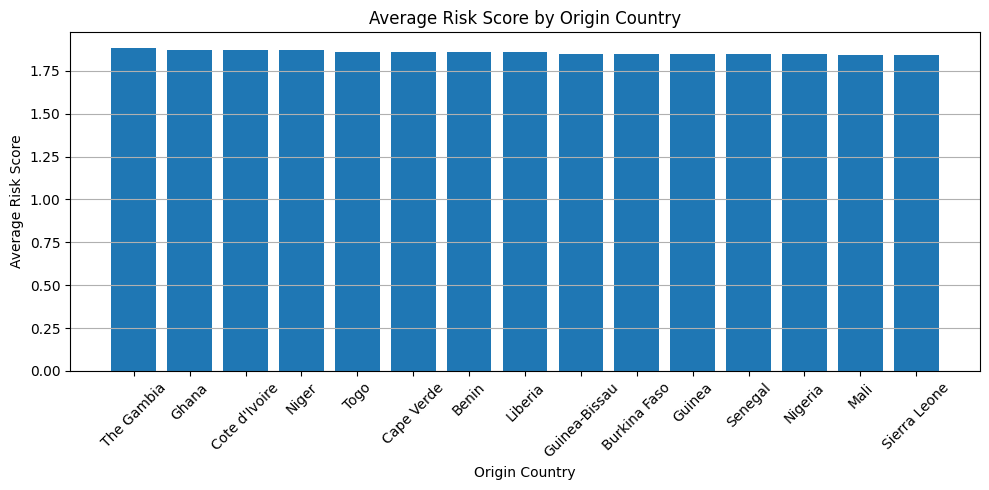

In [44]:
# ============================================================
# Chapter 12A - Visualize Country Risk Ranking
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(

    origin_rank["Origin_Country"],

    origin_rank["Average_Risk"]

)

plt.title("Average Risk Score by Origin Country")

plt.xlabel("Origin Country")

plt.ylabel("Average Risk Score")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

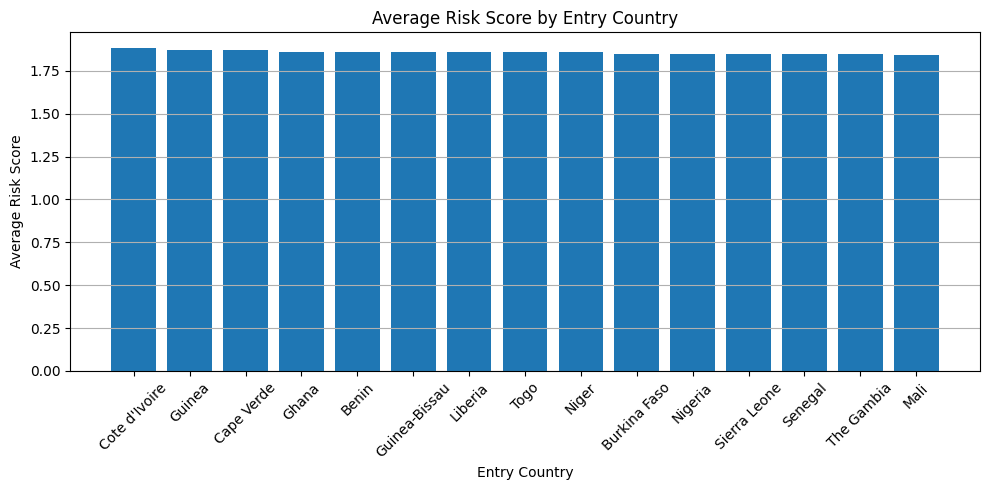

In [45]:
# ============================================================
# Chapter 12B - Visualize Country Risk Ranking
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(

    entry_rank["Entry_Country"],

    entry_rank["Average_Risk"]

)

plt.title("Average Risk Score by Entry Country")

plt.xlabel("Entry Country")

plt.ylabel("Average Risk Score")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

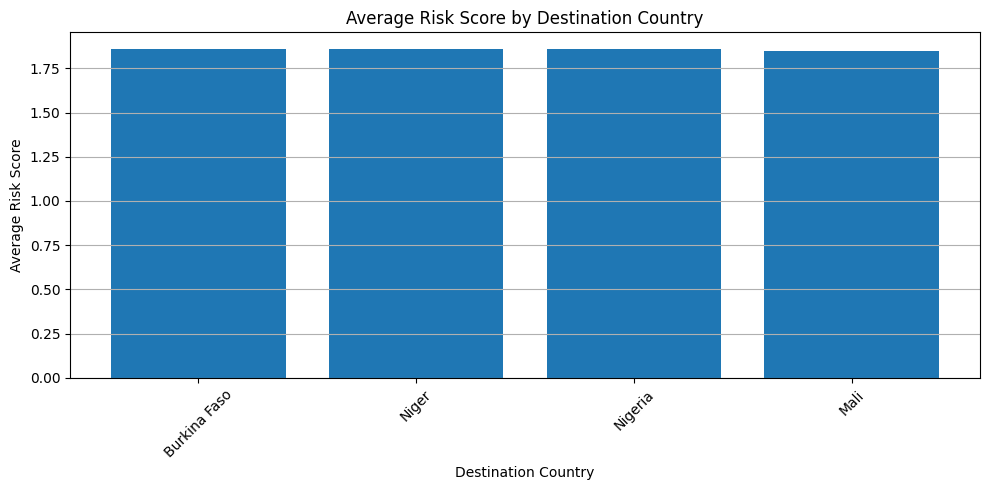

In [46]:
# ============================================================
# Chapter 12C - Visualize Country Risk Ranking
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(

    destination_rank["Destination_Country"],

    destination_rank["Average_Risk"]

)

plt.title("Average Risk Score by Destination Country")

plt.xlabel("Destination Country")

plt.ylabel("Average Risk Score")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

## Chapter 13 - Commodity Risk Ranking

Certain commodities present a higher risk of smuggling, diversion, fraud, or regulatory violations than others. Understanding which goods consistently generate elevated risk scores enables border authorities to prioritize inspections and strengthen targeted enforcement strategies.

This chapter ranks all commodities according to their average composite risk scores, providing valuable intelligence for customs operations, cargo inspection planning, and resource allocation.

# Export Risk Intelligence Reports

The generated risk intelligence tables are exported as CSV files for use in Power BI dashboards, Streamlit applications, SQL analysis, and executive reporting.

These reports provide reusable datasets for downstream analytics and visualization.

In [47]:
# ============================================================
# Chapter 13 - Export Risk Reports
# ============================================================

origin_rank.to_csv(
    "origin_country_risk_ranking.csv",
    index=False
)

entry_rank.to_csv(
    "entry_country_risk_ranking.csv",
    index=False
)

destination_rank.to_csv(
    "destination_country_risk_ranking.csv",
    index=False
)

border_rank.to_csv(
    "border_risk_ranking.csv",
    index=False
)

top20.to_csv(
    "top20_highest_risk_transactions.csv",
    index=False
)

print("Risk intelligence reports exported successfully.")

Risk intelligence reports exported successfully.


# Verify Exported Files

Confirm that all generated reports have been successfully written to the current working directory.

In [48]:
# ============================================================
# Chapter 14 - Verify Export
# ============================================================

import os

csv_files = sorted(

    [file for file in os.listdir()

     if file.endswith(".csv")]

)

print("Generated CSV Files")

for file in csv_files:

    print(file)

Generated CSV Files
border_risk_ranking.csv
destination_country_risk_ranking.csv
entry_country_risk_ranking.csv
origin_country_risk_ranking.csv
risk_distribution.csv
top20_high_risk_transactions.csv
top20_highest_risk_transactions.csv
trade_diversion_transactions.csv


In [49]:
# ============================================================
# Chapter 15 - Verify Export
# ============================================================

import os

for file in sorted(os.listdir()):

    if file.endswith(".csv"):

        print(file)

border_risk_ranking.csv
destination_country_risk_ranking.csv
entry_country_risk_ranking.csv
origin_country_risk_ranking.csv
risk_distribution.csv
top20_high_risk_transactions.csv
top20_highest_risk_transactions.csv
trade_diversion_transactions.csv


# Border Risk Intelligence Summary

## Overview

This notebook developed a quantitative framework for assessing smuggling risk using simulated ECOWAS border trade transactions.

Categorical risk labels were converted into numerical scores to support comparative analysis across transactions, border posts, and participating countries.

---

## Key Activities

- Converted categorical smuggling risk into numerical scores.
- Identified the Top 20 highest-risk transactions.
- Ranked border posts based on average risk scores.
- Ranked origin, entry, and destination countries by average risk.
- Produced visual summaries of country risk patterns.
- Exported reusable analytical datasets.

---

## Business Value

The analytical outputs generated in this notebook can assist border management agencies in:

- Prioritizing inspections.
- Monitoring border security performance.
- Supporting intelligence-led operations.
- Identifying areas requiring increased surveillance.
- Providing decision support for strategic resource allocation.

---

## Deliverables

The following datasets were generated:

- border_risk_ranking.csv
- origin_country_risk_ranking.csv
- entry_country_risk_ranking.csv
- destination_country_risk_ranking.csv
- top20_highest_risk_transactions.csv

These outputs can be integrated into Power BI dashboards, Streamlit applications, SQL reporting, and future machine learning models.

# Risk Distribution Analysis

This section examines the distribution of smuggling risk categories across all simulated border transactions.

Understanding the proportion of **Low**, **Medium**, and **High** risk transactions helps border authorities evaluate the overall security profile of the trade corridor.

In [50]:
# ============================================================
# Chapter 14 - Risk Distribution Analysis
# ============================================================

risk_distribution = (

    df["Smuggling_Risk"]

    .value_counts()

    .sort_index()

)

risk_distribution

,count
Smuggling_Risk,
High,25280
Low,39460
Medium,35260


# Smuggling Risk Distribution

Visualize the number of transactions classified as **Low**, **Medium**, and **High** risk.

This chart provides an overview of the simulated risk landscape across the dataset.

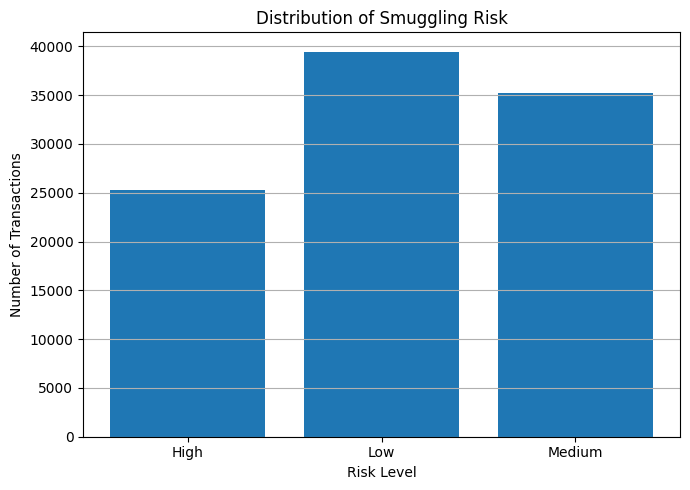

In [51]:
# ============================================================
# Chapter 15 - Visualize Risk Distribution
# ============================================================

plt.figure(figsize=(7,5))

plt.bar(

    risk_distribution.index,

    risk_distribution.values

)

plt.title("Distribution of Smuggling Risk")

plt.xlabel("Risk Level")

plt.ylabel("Number of Transactions")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

# Export Risk Intelligence Reports

Export the generated risk analysis tables for use in Power BI dashboards, Streamlit applications, and executive reporting.

These outputs provide reusable datasets for downstream analytics.

In [52]:
# ============================================================
# Chapter 16 - Export Risk Reports
# ============================================================

origin_rank.to_csv(
    "origin_country_risk_ranking.csv",
    index=False
)

entry_rank.to_csv(
    "entry_country_risk_ranking.csv",
    index=False
)

destination_rank.to_csv(
    "destination_country_risk_ranking.csv",
    index=False
)

border_rank.to_csv(
    "border_risk_ranking.csv",
    index=False
)

top20.to_csv(
    "top20_highest_risk_transactions.csv",
    index=False
)

risk_distribution.to_csv(
    "risk_distribution.csv",
    header=["Count"]
)

print("Risk intelligence reports exported successfully.")

Risk intelligence reports exported successfully.


# Verify Exported Files

Confirm that all generated CSV reports have been successfully exported.

In [53]:
# ============================================================
# Chapter 17 - Verify Export
# ============================================================

import os

csv_files = sorted(

    [file for file in os.listdir()

     if file.endswith(".csv")]

)

print("Generated CSV Files")

for file in csv_files:

    print(file)

Generated CSV Files
border_risk_ranking.csv
destination_country_risk_ranking.csv
entry_country_risk_ranking.csv
origin_country_risk_ranking.csv
risk_distribution.csv
top20_high_risk_transactions.csv
top20_highest_risk_transactions.csv
trade_diversion_transactions.csv


# Border Risk Intelligence Summary

## Overview

This notebook transformed categorical smuggling risk assessments into numerical scores and generated analytical reports to support intelligence-led border management.

## Key Activities

- Converted smuggling risk categories into numerical scores.
- Identified the Top 20 highest-risk transactions.
- Ranked border posts by average risk.
- Ranked origin, entry, and destination countries.
- Analyzed the distribution of risk categories.
- Exported reusable datasets for reporting and dashboards.

## Business Value

The outputs from this notebook support:

- Intelligence-led inspection planning.
- Resource allocation across border posts.
- Identification of high-risk trade corridors.
- Strategic monitoring of border operations.

## Deliverables

- `border_risk_ranking.csv`
- `origin_country_risk_ranking.csv`
- `entry_country_risk_ranking.csv`
- `destination_country_risk_ranking.csv`
- `top20_highest_risk_transactions.csv`
- `risk_distribution.csv`

# Key Findings & Strategic Insights


The risk scoring engine successfully integrated multiple operational indicators into a single composite intelligence metric capable of prioritizing border transactions according to their relative level of risk.

The analysis identified variations in operational risk across border posts, neighboring countries, and commodity categories, demonstrating how data-driven intelligence can support evidence-based border management.

High-risk transactions were isolated for immediate operational attention, while automated recommendations were generated to improve inspection consistency and resource utilization.

The exported datasets produced in this notebook will serve as core inputs for the subsequent machine learning, anomaly detection, forecasting, geospatial visualization, and Streamlit dashboard modules developed later in this project.

Overall, this notebook establishes the analytical foundation for an intelligent, data-driven ECOWAS Border Intelligence Analytics Platform capable of supporting strategic planning, operational decision-making, and regional border security.